In [2]:
import pandas as pd

In [3]:
dados = pd.read_csv('https://raw.githubusercontent.com/LuizinhoXT/Python/refs/heads/main/machine_learning/nlp_machine_learning/dataset_avaliacoes.csv')

In [4]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [5]:
dados.value_counts('sentimento')

sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [6]:
print('positivo \n\n', dados.avaliacao[0])

positivo 

 Esse smartphone superou minhas expectativas, recomendo


In [7]:
print('negativo \n\n', dados.avaliacao[1])

negativo 

 o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
# teste de vetorização para entender o funcionamento do algoritimo

texto = ['Esse smartphone superou minhas expectativas, recomendo', 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [10]:
# Matrix esparsa é o retorno de bag_of_words que acontece quando temos vários 0's dentro de uma matriz
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 15 stored elements and shape (2, 15)>

In [11]:
# Através da vetorização, criamos uma tabela em que os elementos escalam de maneira horizontal, gerando assim uma classificação binária que avalia se determinada palavra existe ou não exister em determinado registro de dados.

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words,columns=vetorizar.get_feature_names_out())

matriz_esparsa

,cheiro,desagradavel,esse,expectativas,incomoda,minhas,muito,nao,pra,quem,recomendo,recomendoo,se,smartphone,superou
0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1
1,1,1,0,0,1,0,1,1,1,1,0,1,1,0,0


In [12]:
# A dimensão na pós vetorização aumenta horizontalmente e isso se mostra no Output dessa célula com +23k de colunas.
# Isso é um problema pois é computacionalmente caro

vetorizar = CountVectorizer(lowercase=False)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

(15501, 23352)


In [13]:
# Otimizando o código para limitar a quantidade de features geradas pela vetorização


vetorizar = CountVectorizer(lowercase=False, max_features=50)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

# A limitação de features considera as palavras que tem maior ocorrencia dentro da dos dados


(15501, 50)


In [14]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns= vetorizar.get_feature_names_out())
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
# Separação em treino teste split
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados.sentimento, random_state=4978)

In [16]:
# Aplicando algorítmo de Regressão Logística 
from sklearn.linear_model import LogisticRegression

regresssao_logistica = LogisticRegression()
regresssao_logistica.fit(x_treino, y_treino)
acuracia = regresssao_logistica.score(x_teste, y_teste)
acuracia

0.7982456140350878

- Crie uma função chamada classificar_texto, que aceite três parâmetros: o nome do DataFrame, o nome da coluna contendo as avaliações de texto e o nome da coluna correspondente aos sentimentos;
- Utilize a classe CountVectorizer para transformar o texto em um vetor bag of words, com um número máximo de 50 features;
- Separe os dados em conjuntos de treino e teste utilizando train_test_split;
- Crie um modelo de regressão logística e ajuste-o aos dados de treino;
- Calcule e retorne a acurácia do modelo para os dados de teste;
- Retorne o valor da acurácia.

In [17]:
def classificar_testo(df,col_ava_texto, sentimento):
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    vetorizar = CountVectorizer(lowercase=False, max_features=50)

    bag_of_words = vetorizar.fit_transform(df[col_ava_texto])
    print(bag_of_words.shape)

    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados[sentimento], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    regresssao_logistica = LogisticRegression()
    regresssao_logistica.fit(x_treino, y_treino)
    acuracia = regresssao_logistica.score(x_teste, y_teste)
   
    return print(f"\nAcurácia do modelo com a coluna '{col_ava_texto}': {acuracia * 100:.2f}%")



In [18]:
classificar_testo(dados,'avaliacao','sentimento')


(15501, 50)

Acurácia do modelo com a coluna 'avaliacao': 79.82%


#### Resumo até aqui

- Explorar dados textuais;
- Utilizar a técnica de Bag of words para converter textos em vetores numéricos;
- Separar os dados em treino e teste;
- Treinar o modelo de regressão logística;
- Obter a acurácia do modelo nos dados de teste.

In [19]:
! pip install wordcloud
from wordcloud import WordCloud

In [20]:
todas_palavras = [texto for texto in dados.avaliacao]
todas_palavras

['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [21]:
todas_palavras = ' '.join([texto for texto in dados.avaliacao])
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [22]:
nuvem_palavras = WordCloud().generate(todas_palavras)

<function matplotlib.pyplot.show(close=None, block=None)>

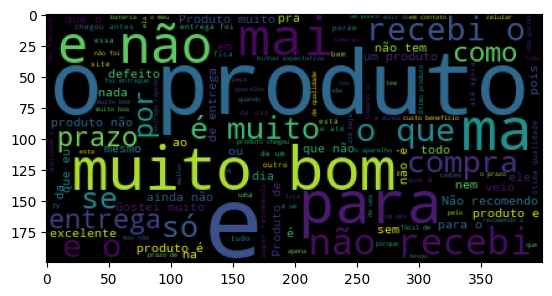

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(nuvem_palavras)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

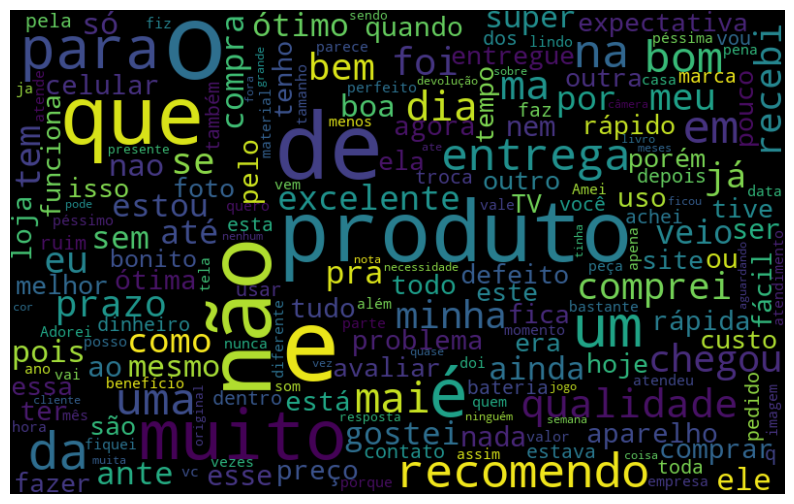

In [24]:
import matplotlib.pyplot as plt

novo_nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(todas_palavras)

plt.figure(figsize=(10,7))
plt.imshow(novo_nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show

In [25]:
def nuvem_palavras(dados,col_texto,sentimento):
    texto_sentimento = dados.query(f"sentimento == '{sentimento}'")[col_texto]

    texto_unido = ''.join(texto_sentimento)

    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(texto_unido)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.show

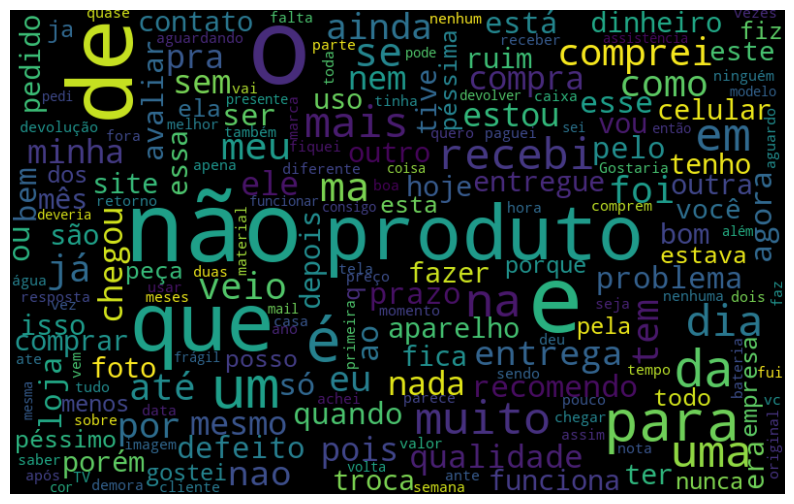

In [26]:
nuvem_palavras(dados,'avaliacao','negativo')

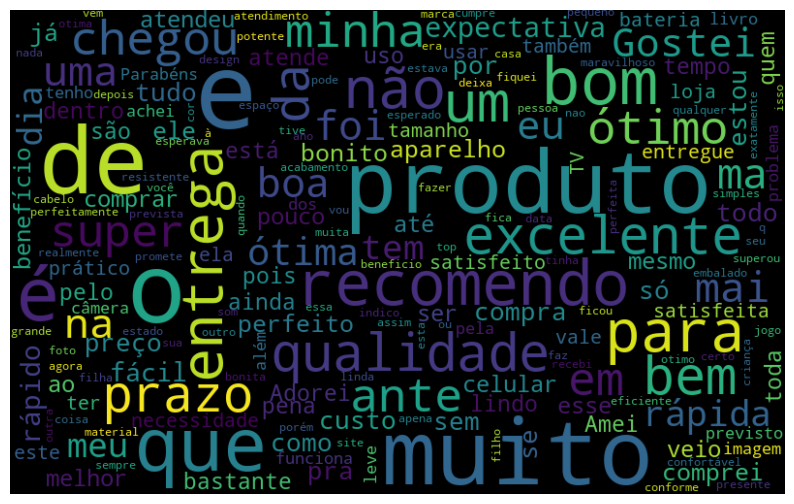

In [27]:
nuvem_palavras(dados,'avaliacao','positivo')

In [28]:
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [29]:
! pip install nltk



In [30]:
import nltk

In [31]:
frases = ['um produto bom', 'um produto ruim']

In [32]:
frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [33]:
# Aplicando o processo de tokenização que irá separar o texto em palavras menores

from nltk import tokenize

frase = 'o produto é excelente e a entrega foi muita rápida!'
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['o', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muita', 'rápida!']


In [52]:
token_frase = token_espaco.tokenize(todas_palavras)
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [ ]:
df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})

In [44]:
df_frequencia.head()

,palavra,frequencia
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


In [45]:
df_frequencia.nlargest(columns='frequencia',n=10)


,palavra,frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


[Text(0, 0.5, 'Contagem')]

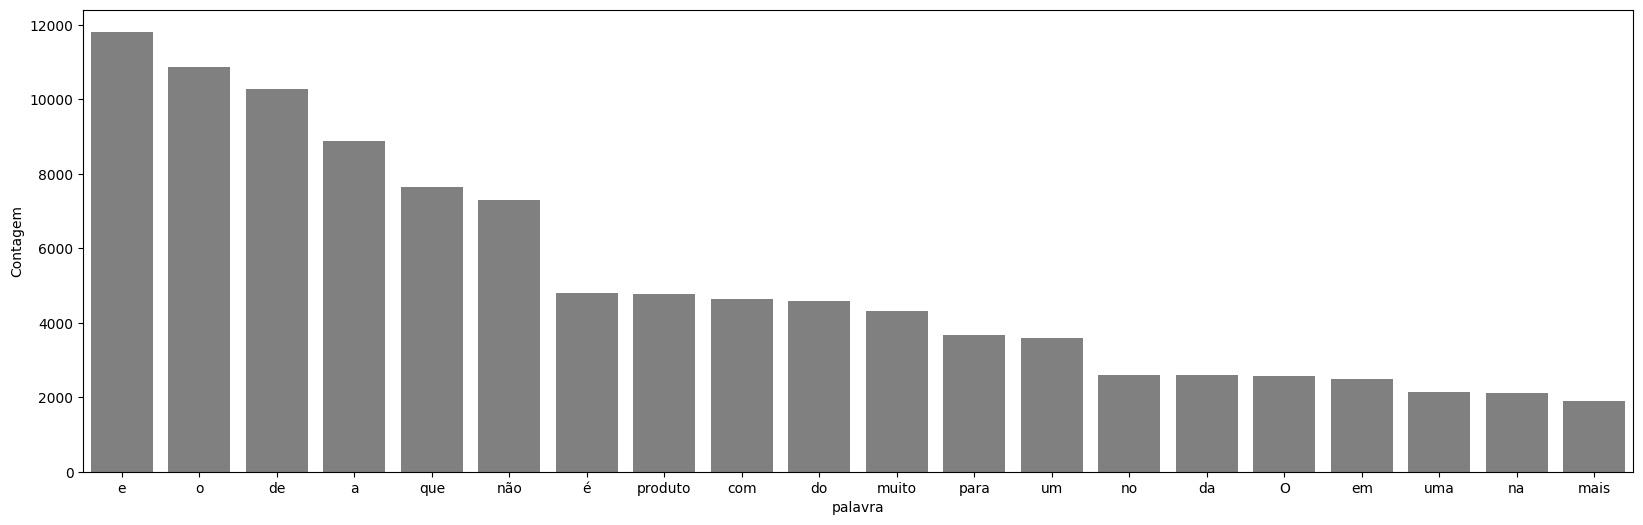

In [51]:
import seaborn as sns

plt.figure(figsize=(20,6))
ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=20), x='palavra', y='frequencia',color='grey')
ax.set(ylabel='Contagem')

- Receba três parâmetros: o nome do DataFrame contendo a coluna com o texto, o nome da coluna de texto e a quantidade de palavras mais frequentes a serem exibidas;
- Concatene todas as palavras presentes em uma determinada coluna de um DataFrame;
- Calcule a frequência de cada palavra usando a biblioteca NLTK;
- Converta os resultados em um DataFrame contendo duas colunas: "Palavra" e "Frequência";
- Selecione as palavras mais frequentes, de acordo com a quantidade especificada pelo usuário;
- Plote um gráfico de barras exibindo a frequência dessas palavras utilizando a biblioteca seaborn.

In [54]:
def grafico_frequencia(df,nm_col_ava,qty):

    todas_palavras = ' '.join([texto for texto in df[nm_col_ava]])
    token_frase = token_espaco.tokenize(todas_palavras)
    frequencia = nltk.FreqDist(token_frase)

    df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})
    
    plt.figure(figsize=(20,6))
    ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=qty), x='palavra', y='frequencia',color='grey')
    ax.set(ylabel='Contagem')


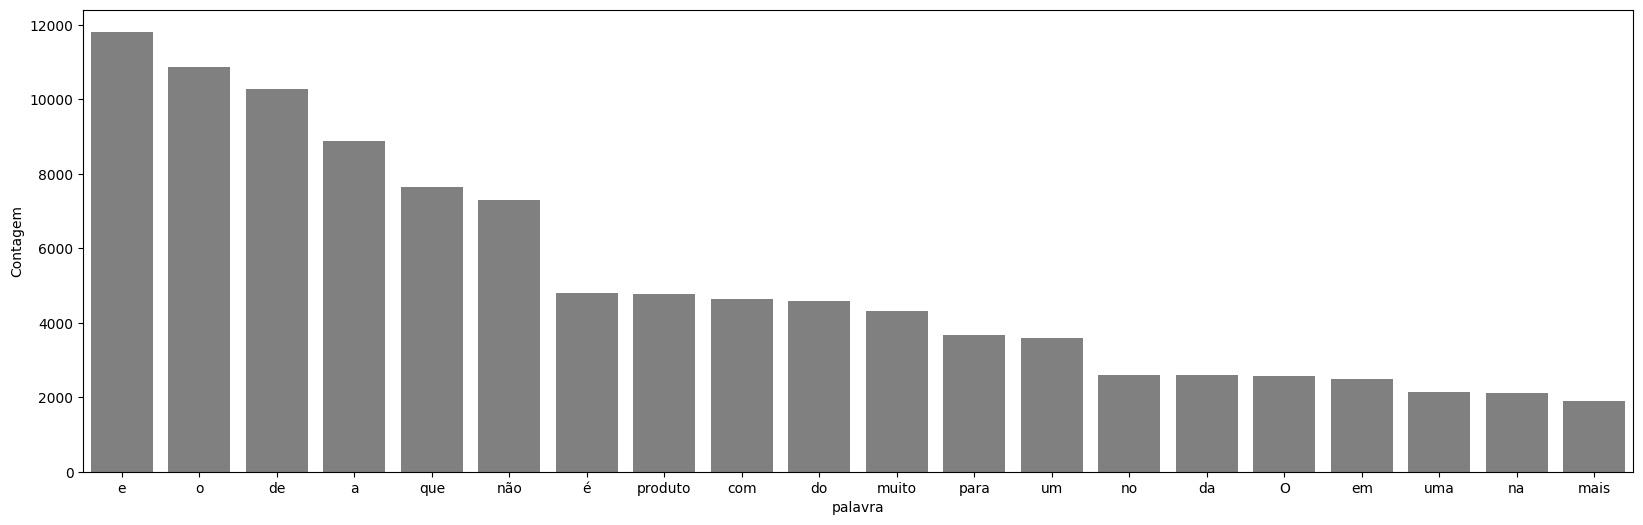

In [55]:
grafico_frequencia(dados,'avaliacao',20)

- Utilizar a biblioteca wordcloud para criar nuvens de palavras;
- Criar uma função para filtrar os sentimentos;
- Aplicar a tokenização com a biblioteca NLTK;
- Calcular a frequência das palavras com a biblioteca NLTK;
- Criar um gráfico com as palavras mais frequentes.